In [2]:
import pandas as pd
import csv
import math
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.signal import find_peaks
import numpy as np
pd.set_option('display.float_format', lambda x: '%e' % x)

TITLE_FONTSIZE = 14
AXES_FONTSIZE = 12

def read_rigol_csv(csv_file_name):
    with open(csv_file_name) as f:
        rows = list(csv.reader(f))

    i = 0
    while rows[0][i] != "":
        i = i + 1

    numcols = i - 2
    t0 = float(rows[1][numcols])
    dT = float(rows[1][numcols+1])

    data = pd.read_csv(csv_file_name, usecols=range(0, numcols), skiprows=[1])
    data['X'] = t0 + data['X'] * dT

    return data, t0, dT
    
def get_channel_data(data, channel_name):
    if channel_name in data.columns:
        return data[channel_name].rolling(10, min_periods=1, center=True).mean()
        #return data[channel_name]
    return None

def analyze_rigol_data(data, has_ch1, has_ch2, x1, x2, drainx):
    slope, ch2_mean, peak_vsh, max_vdrain = None, None, None, None
    
    if x1 is not None and x2 is not None:
        subset = data[(data['X'] >= x1) & (data['X'] <= x2)]
        
        if has_ch1 and not subset.empty:
            result = linregress(subset['X'], subset['CH1'])
            slope = float(result.slope)
            peak_vsh = float(data.iloc[(data['X'] - x2).abs().argsort()[:1]]['CH1'].values[0])

        if has_ch2:
            ch2_mean = float(subset['CH2'].mean())
            max_vdrain = data.iloc[(data['X'] - drainx).abs().argsort()[:1]]['CH2'].item()
    elif has_ch2:
        max_vdrain = data.iloc[(data['X'] - drainx).abs().argsort()[:1]]['CH2'].item()
            
    return slope, ch2_mean, peak_vsh, max_vdrain

def plot_rigol(
    filepath, 
    title, 
    ch1label="Shunt Voltage (Vsh)", 
    ch2label="Drain Voltage (Vd)", 
    ch3label="Cathode Voltage (Vk)", 
    x1=None, 
    x2=None, 
    duty_points=None, 
    drainx=0.5e-5
): 
    data, t0, dT = read_rigol_csv(f"data/{filepath}.csv")
    
    channels = {
        'CH1': {'label': ch1label, 'color': '#0072BD', 'axis': 0},
        'CH2': {'label': ch2label, 'color': '#f74519', 'axis': 1},
        'CH3': {'label': ch3label, 'color': '#FFBF00', 'axis': 1}
    }

    for ch in channels:
        smoothed = get_channel_data(data, ch)
        if smoothed is not None:
            data[ch] = smoothed

    slope, ch2_mean, peak_vsh, max_vdrain = analyze_rigol_data(
        data, 'CH1' in data, 'CH2' in data, x1, x2, drainx
    )

    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax2 = ax1.twinx()
    axes = [ax1, ax2]
    
    handles, labels = [], []

    for ch, config in channels.items():
        if ch not in data:
            continue
            
        ax = axes[config['axis']]
        ln, = ax.plot(data['X'], data[ch], label=config['label'], color=config['color'], alpha=0.9)
        
        handles.append(ln)
        labels.append(config['label'])

    if 'CH1' in data and x1 is not None and x2 is not None:
        subset = data[(data['X'] >= x1) & (data['X'] <= x2)]
        fit = slope * subset['X'] + (peak_vsh - slope * x2)
        ax1.plot(subset['X'], fit, color="red", lw=2, ls="--", label='Linear Fit')
        ax1.plot(x2, peak_vsh, 'r*', markersize=10)

    if 'CH2' in data and duty_points is not None:
        for px in duty_points:
            idx = (data['X'] - px).abs().idxmin()
            py = data.loc[idx, 'CH2']
            ax2.plot(px, py, 'go', mfc='none', markersize=8)

    ax1.set_xlabel("Time (s)", fontsize=AXES_FONTSIZE)
    ax1.set_ylabel(ch1label, color=channels['CH1']['color'], fontsize=AXES_FONTSIZE)
    
    if 'CH3' in data:
        ax2.set_ylabel(f"{ch2label} / {ch3label}", color='#FB820D', fontsize=AXES_FONTSIZE)
    else:
        ax2.set_ylabel(f"{ch2label}", color=channels['CH2']['color'], fontsize=AXES_FONTSIZE)
    
    ax1.legend(handles, labels, loc='upper left', frameon=True)
    plt.title(title, fontsize=TITLE_FONTSIZE)
    plt.tight_layout()
    plt.show()
    return (slope, ch2_mean, peak_vsh, max_vdrain)

def plot_multiple_rigol_files(file_list, x_limits=None, custom_labels=None):
    """
    Reads multiple Rigol CSVs and overlays them on two separate plots.
    
    Args:
        file_list: List of filenames (e.g., ["test1", "test2"]) without .csv extension.
        custom_labels: List of labels for the legend. Defaults to filenames.
    """
    fig_sh, ax_sh = plt.subplots(figsize=(10, 6))

    colors = plt.cm.viridis(np.linspace(0, 1, len(file_list)))

    for i, filename in enumerate(file_list):
        filepath = f"data/{filename}.csv"
        try:
            data, t0, dT = read_rigol_csv(filepath)
        except FileNotFoundError:
            print(f"Warning: {filepath} not found. Skipping.")
            continue

        v_shunt = data['CH1'] #get_channel_data(data, 'CH1')
        label = custom_labels[i] if custom_labels else filename
        if v_shunt is not None:
            ax_sh.plot(data['X'], v_shunt, label=label, color=colors[i], alpha=0.8)

    for ax in [ax_sh]:
        if x_limits:
            ax.set_xlim(x_limits)
        ax.set_xlabel("Time (s)", fontsize=AXES_FONTSIZE)
        ax.grid(True, linestyle='--', alpha=0.5)

    ax_sh.set_title("Shunt Voltage: Output Voltage Comparison", fontsize=TITLE_FONTSIZE)
    ax_sh.set_xlabel("Time (s)", fontsize=AXES_FONTSIZE)
    ax_sh.set_ylabel("Voltage (V)", fontsize=AXES_FONTSIZE)
    ax_sh.legend(loc='best', fontsize='small', ncol=2, title="Output Voltage")
    ax_sh.grid(True, linestyle='--', alpha=0.6)
    fig_sh.tight_layout()
    
    plt.show()

### Q1: At 10V, take and save a baseline Vsh/Vdrain measurement.

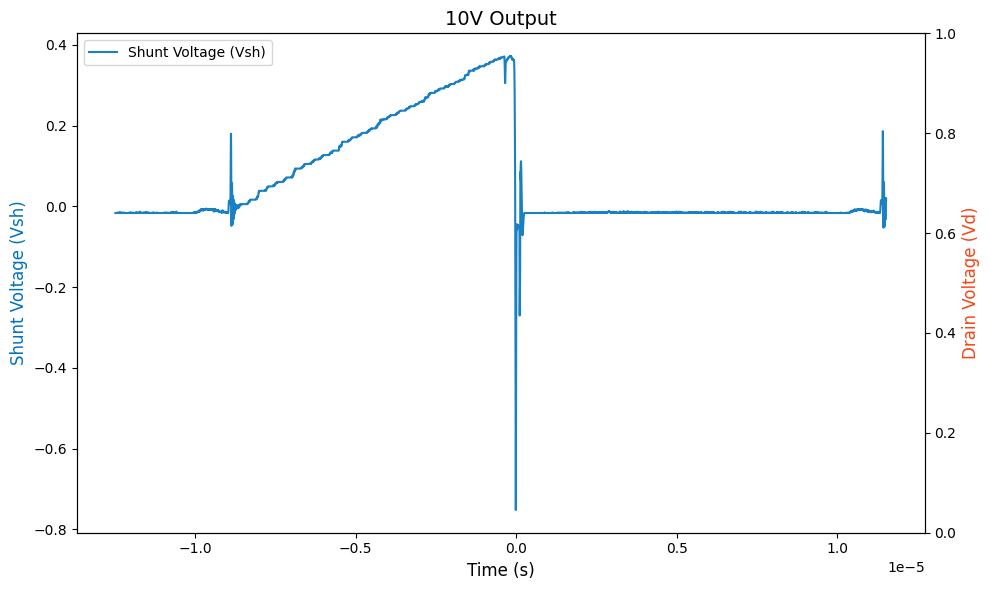

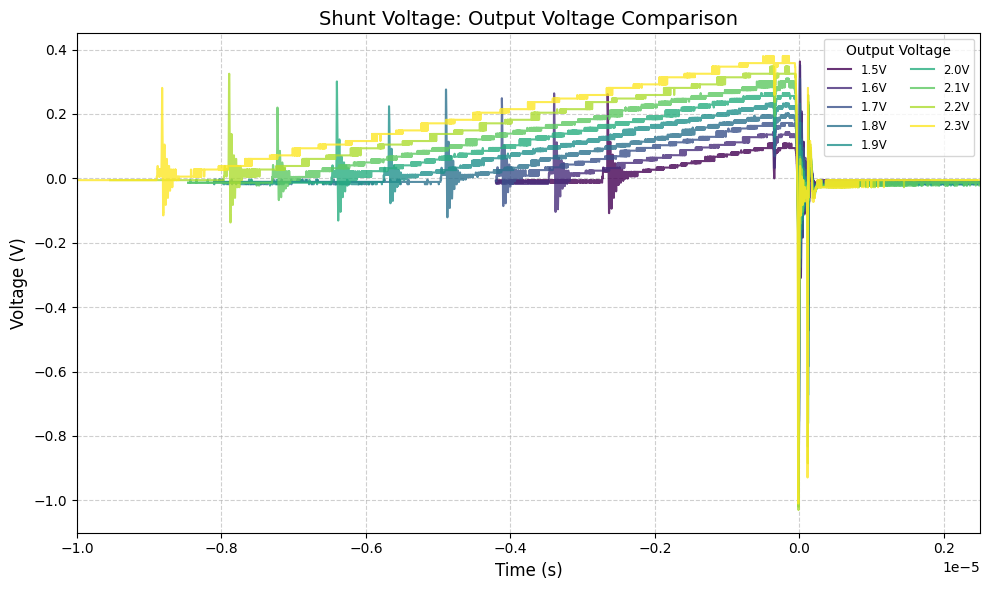

,V Comp Offset (V),Vout (V),Input Current (A)
0,1.500,3.216,0.180
1,1.600,4.250,0.270
2,1.700,5.099,0.390
3,1.800,6.039,0.530
4,1.900,7.030,0.710
5,2.000,7.970,0.890
6,2.100,8.890,1.100
7,2.200,9.810,1.340
8,2.300,10.750,1.610


In [4]:
plot_rigol("2_3v_q1", "10V Output")
filenames = ["1_5v", "1_6v", "1_7v", "1_8v", "1_9v", "2_0v", "2_1v", "2_2v", "2_3v"]
labels = ["1.5V", "1.6V", "1.7V", "1.8V", "1.9V", "2.0V", "2.1V", "2.2V", "2.3V"]
plot_multiple_rigol_files(filenames, [-1e-5, 0.25e-5], labels)

pd.options.display.float_format = '{:.3f}'.format

v_comp_offset = np.arange(1.5, 2.4, 0.1)
vout = [3.216, 4.250, 5.099, 6.039, 7.030, 7.970, 8.89, 9.81, 10.75]
input_current = [0.18, 0.27, 0.39, 0.53, 0.71, 0.89, 1.10, 1.34, 1.61]

df = pd.DataFrame({
    'V Comp Offset (V)': v_comp_offset,
    'Vout (V)': vout,
    'Input Current (A)': input_current
})
df

### Q2: Why is the red output LED blinking during the sweep?

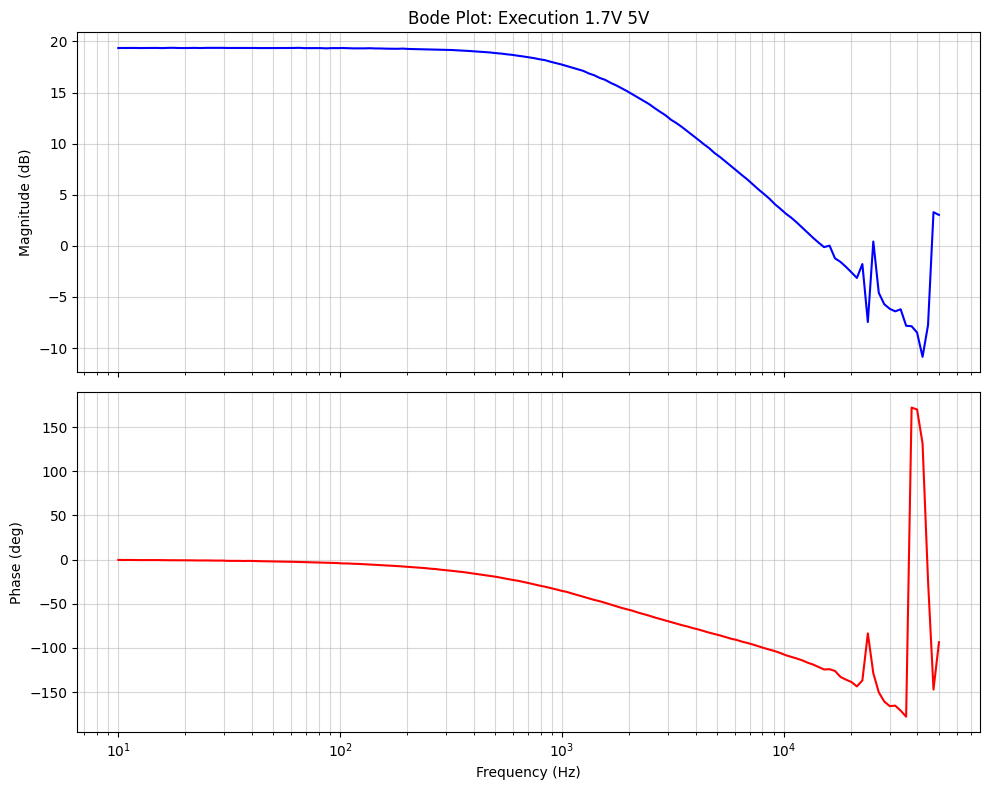

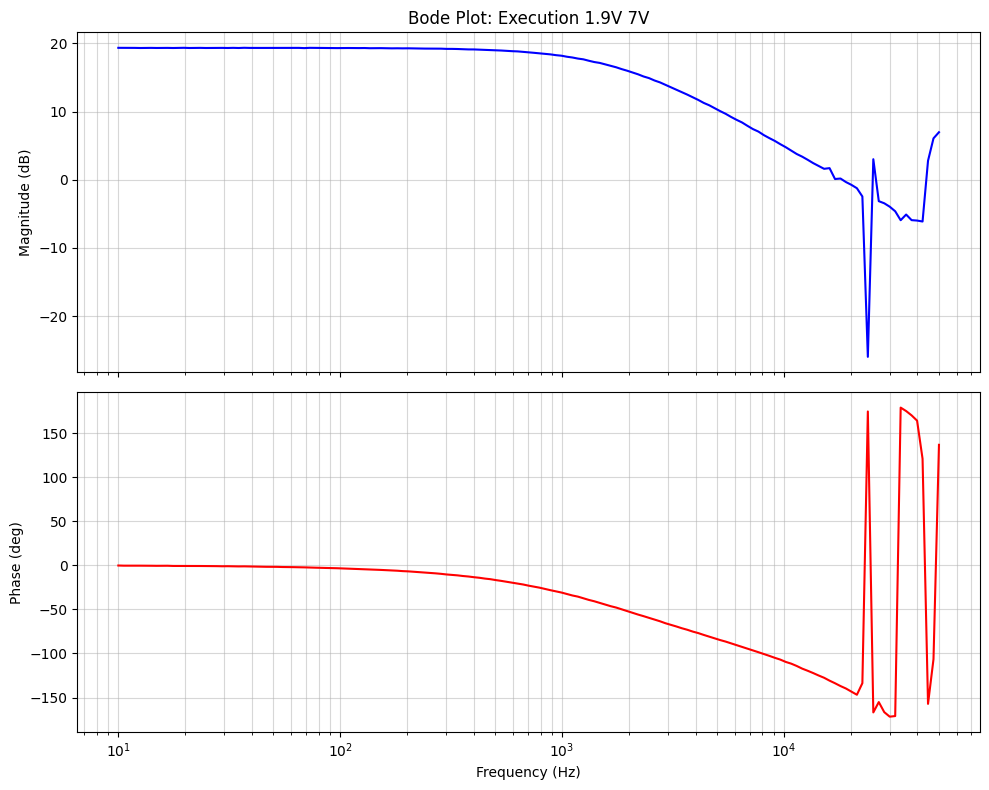

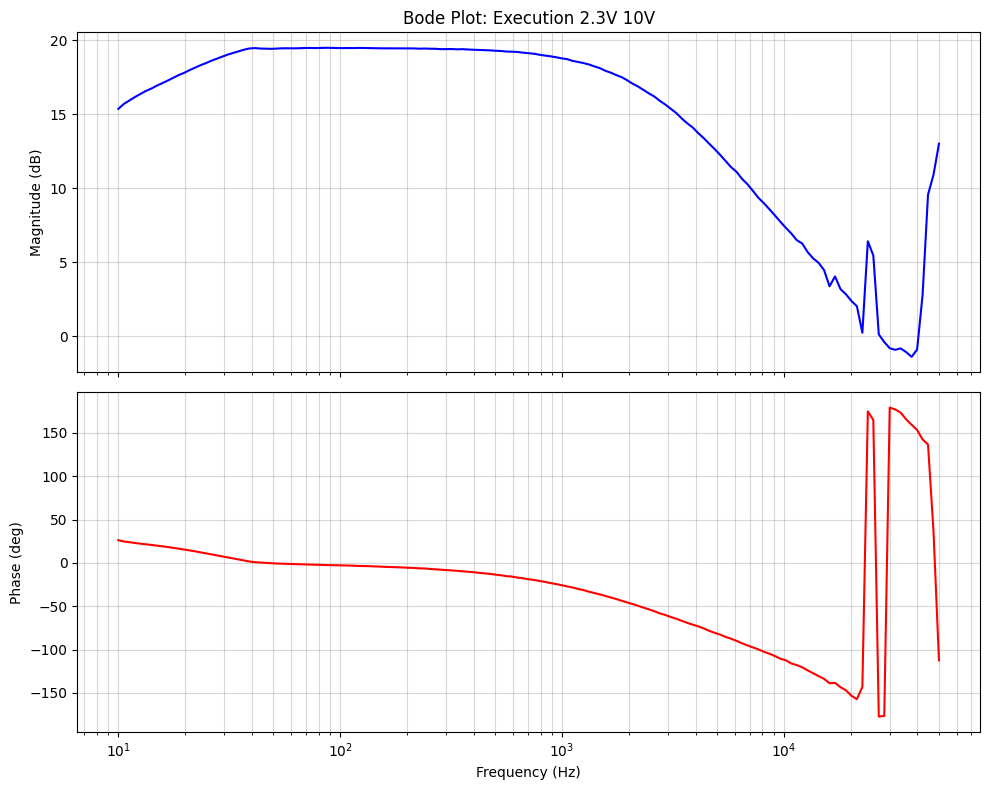

In [14]:
def process_digilent(filename):
    """
    Reads a Digilent WaveForms CSV file and returns a cleaned pandas DataFrame.
    Automatically skips metadata lines starting with '#'.
    """
    file_path = "data/execution/Execution_"+filename+".csv"
    df = pd.read_csv(file_path, comment='#')
    return df

def plot_bode(filename, title="Bode Plot"):
    """
    Generates a Bode plot (Magnitude and Phase) from the DataFrame.
    Expects columns: 'Frequency (Hz)', 'Channel 2 Magnitude (dB)', and 'Channel 2 Phase (deg)'.
    """
    df = process_digilent(filename)
    freq = df['Frequency (Hz)']
    mag = df['Channel 2 Magnitude (dB)']
    phase = df['Channel 2 Phase (deg)']
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    
    ax1.semilogx(freq, mag, color='blue', linewidth=1.5)
    ax1.set_ylabel('Magnitude (dB)')
    ax1.set_title(title)
    ax1.grid(True, which="both", ls="-", alpha=0.5)

    ax2.semilogx(freq, phase, color='red', linewidth=1.5)
    ax2.set_xlabel('Frequency (Hz)')
    ax2.set_ylabel('Phase (deg)')
    ax2.grid(True, which="both", ls="-", alpha=0.5)
    
    plt.tight_layout()
    plt.show()

plot_bode('1_7_V_5V', title="Bode Plot: Execution 1.7V 5V")
plot_bode('1_9_V_7V', title="Bode Plot: Execution 1.9V 7V")
plot_bode('2_3_V_10V', title="Bode Plot: Execution 2.3V 10V")

### Q3: By inspecting the measurements, establish an expression for Ipk = f(offest), where "offset" corresponds to the value that was set in the Wavegen "offset" field.

### Q4: Does year expression for Ipk = f(offset) match what the circuit predicts?

### Q5: Document your observations

### Q6: By inspecting the measurements, establish an expression for the V = f(offset), where "V" is the output voltage.

### Q7: Do the measurements match what our analysis predicts?

### Q8: Documents your observations.

### Q9: Plot the Bode plots taken at 5V, 7V and 10V into one common graph so that they can be compared (channel 2 magnitude and phase).

### Q10: Comment on how the plots change with output voltage.

### Q11: Identify the DC gain (gain of transfer function at 0 Hz). How does it relate to the electrical parameters of the converter?

### Q12: Can you identify a simple transfer function that will approximate the Bode plots measured?

### Q13: Can you identify a pole and its frequency? How does it relate to the electrical parameters of the converter?

### Q14: Do you think that there might be other poles (and zeroes) in the control-to-output transfer function?

### Q15: Document your observations.